In [1]:
# ── Standard libraries ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Scorecard specific ───────────────────────────────────────────────────────
# scorecardpy: industry standard library for WOE/IV in Python
# Built specifically for credit scorecard development
import scorecardpy as sc

# ── Display settings ─────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

print('Libraries loaded successfully ✓')

/Users/shivamverma/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Libraries loaded successfully ✓


In [2]:
# ── Load original raw data for WOE binning ────────────────────────────────────
# We go back to the raw data because scorecardpy needs original values
# not the one-hot encoded version from notebook 02

base = os.path.join(os.path.expanduser('~'), 'Desktop',
                    'Credit-Risk-Analytics-Portfolio',
                    '01_scorecard_development')

raw_path = os.path.join(base, 'data', 'application_train.csv')
df_raw   = pd.read_csv(raw_path)

print(f'Raw data loaded ✓  Shape: {df_raw.shape}')
print(f'Target rate: {df_raw["TARGET"].mean()*100:.2f}%')

Raw data loaded ✓  Shape: (307511, 122)
Target rate: 8.07%


In [3]:
# ── Fix known anomalies before WOE binning ────────────────────────────────────
# Same fixes as notebook 02 — must be applied here too

# Fix DAYS_EMPLOYED anomaly
df_raw['DAYS_EMPLOYED'] = df_raw['DAYS_EMPLOYED'].replace(365243, np.nan)

# Fix CODE_GENDER XNA
if 'CODE_GENDER' in df_raw.columns:
    df_raw['CODE_GENDER'] = df_raw['CODE_GENDER'].replace('XNA', np.nan)

# Convert DAYS to years
df_raw['AGE_YEARS']        = -df_raw['DAYS_BIRTH'] / 365
df_raw['EMPLOYMENT_YEARS'] = -df_raw['DAYS_EMPLOYED'] / 365

# Create ratio features
df_raw['CREDIT_INCOME_RATIO']  = df_raw['AMT_CREDIT'] / (df_raw['AMT_INCOME_TOTAL'] + 1)
df_raw['ANNUITY_INCOME_RATIO'] = df_raw['AMT_ANNUITY'] / (df_raw['AMT_INCOME_TOTAL'] + 1)
df_raw['CREDIT_GOODS_RATIO']   = df_raw['AMT_CREDIT'] / (df_raw['AMT_GOODS_PRICE'] + 1)
df_raw['EMPLOYMENT_AGE_RATIO'] = df_raw['EMPLOYMENT_YEARS'] / (df_raw['AGE_YEARS'] + 1)

print('Anomalies fixed and features created ✓')
print(f'Shape: {df_raw.shape}')

Anomalies fixed and features created ✓
Shape: (307511, 128)


In [4]:
# ── Select columns for WOE analysis ──────────────────────────────────────────
# We focus on the most business-relevant variables first
# Avoid columns with >40% missing — same threshold as preprocessing

missing_pct = df_raw.isnull().mean()
valid_cols  = missing_pct[missing_pct <= 0.40].index.tolist()

# Always include TARGET
if 'TARGET' not in valid_cols:
    valid_cols.append('TARGET')

# Remove ID column — not a predictor
valid_cols = [c for c in valid_cols if c != 'SK_ID_CURR']

df_woe = df_raw[valid_cols].copy()

print(f'Columns selected for WOE analysis: {len(valid_cols)}')
print(f'Shape: {df_woe.shape}')

Columns selected for WOE analysis: 78
Shape: (307511, 78)


In [6]:
from sklearn.model_selection import train_test_split

# ── Split before WOE — this is the correct order ─────────────────────────────
train_df, oot_df = train_test_split(
    df_woe,
    test_size=0.2,
    random_state=42,
    stratify=df_woe['TARGET']
)

print('Train / OOT Split')
print('='*45)
print(f'Train : {len(train_df):,} rows | Default rate: {train_df["TARGET"].mean()*100:.2f}%')
print(f'OOT   : {len(oot_df):,} rows | Default rate: {oot_df["TARGET"].mean()*100:.2f}%')

Train / OOT Split
Train : 246,008 rows | Default rate: 8.07%
OOT   : 61,503 rows | Default rate: 8.07%


In [7]:
# ── Calculate IV using scorecardpy ────────────────────────────────────────────
# iv_df returns a summary table with IV for every variable
# This is calculated on TRAIN data only

print('Calculating IV for all variables...')
print('This may take 2-3 minutes for large datasets...')

iv_df = sc.iv(train_df, y='TARGET')

print('IV calculation complete ✓')

Calculating IV for all variables...
This may take 2-3 minutes for large datasets...
IV calculation complete ✓


In [8]:
iv_df

,variable,info_value
40,CREDIT_INCOME_RATIO,1.0708
58,ANNUITY_INCOME_RATIO,0.7800
38,AMT_ANNUITY,0.6933
4,EMPLOYMENT_YEARS,0.5027
61,DAYS_EMPLOYED,0.5027
59,DAYS_REGISTRATION,0.4710
23,EMPLOYMENT_AGE_RATIO,0.4516
54,EXT_SOURCE_2,0.4387
28,CREDIT_GOODS_RATIO,0.4314
45,AMT_CREDIT,0.4231


In [9]:
# ── View IV summary table ─────────────────────────────────────────────────────
# Sort by IV descending — most predictive variables first

iv_summary = iv_df.sort_values('info_value', ascending=False).reset_index(drop=True)
iv_summary.columns = ['Variable', 'IV']

# Add interpretation column
def iv_interpretation(iv):
    if iv < 0.02:   return 'Useless'
    elif iv < 0.10: return 'Weak'
    elif iv < 0.30: return 'Medium'
    elif iv < 0.50: return 'Strong'
    else:           return 'Suspicious — check leakage'

iv_summary['Interpretation'] = iv_summary['IV'].apply(iv_interpretation)

print('Full IV Summary Table')
print('='*65)
print(iv_summary.to_string(index=False))

Full IV Summary Table
                   Variable     IV             Interpretation
        CREDIT_INCOME_RATIO 1.0708 Suspicious — check leakage
       ANNUITY_INCOME_RATIO 0.7800 Suspicious — check leakage
                AMT_ANNUITY 0.6933 Suspicious — check leakage
           EMPLOYMENT_YEARS 0.5027 Suspicious — check leakage
              DAYS_EMPLOYED 0.5027 Suspicious — check leakage
          DAYS_REGISTRATION 0.4710                     Strong
       EMPLOYMENT_AGE_RATIO 0.4516                     Strong
               EXT_SOURCE_2 0.4387                     Strong
         CREDIT_GOODS_RATIO 0.4314                     Strong
                 AMT_CREDIT 0.4231                     Strong
                 DAYS_BIRTH 0.4046                     Strong
                  AGE_YEARS 0.4046                     Strong
               EXT_SOURCE_3 0.3920                     Strong
            DAYS_ID_PUBLISH 0.3515                     Strong
     DAYS_LAST_PHONE_CHANGE 0.2226              

In [10]:
# ── Save IV summary ───────────────────────────────────────────────────────────
iv_summary.to_csv(os.path.join(base, 'outputs', 'iv_summary.csv'), index=False)
print('IV summary saved ✓')

# Quick count by category
print('\nVariable Count by IV Category:')
print('='*40)
print(iv_summary['Interpretation'].value_counts().to_string())

IV summary saved ✓

Variable Count by IV Category:
Interpretation
Useless                       47
Weak                          13
Strong                         9
Suspicious — check leakage     5
Medium                         3


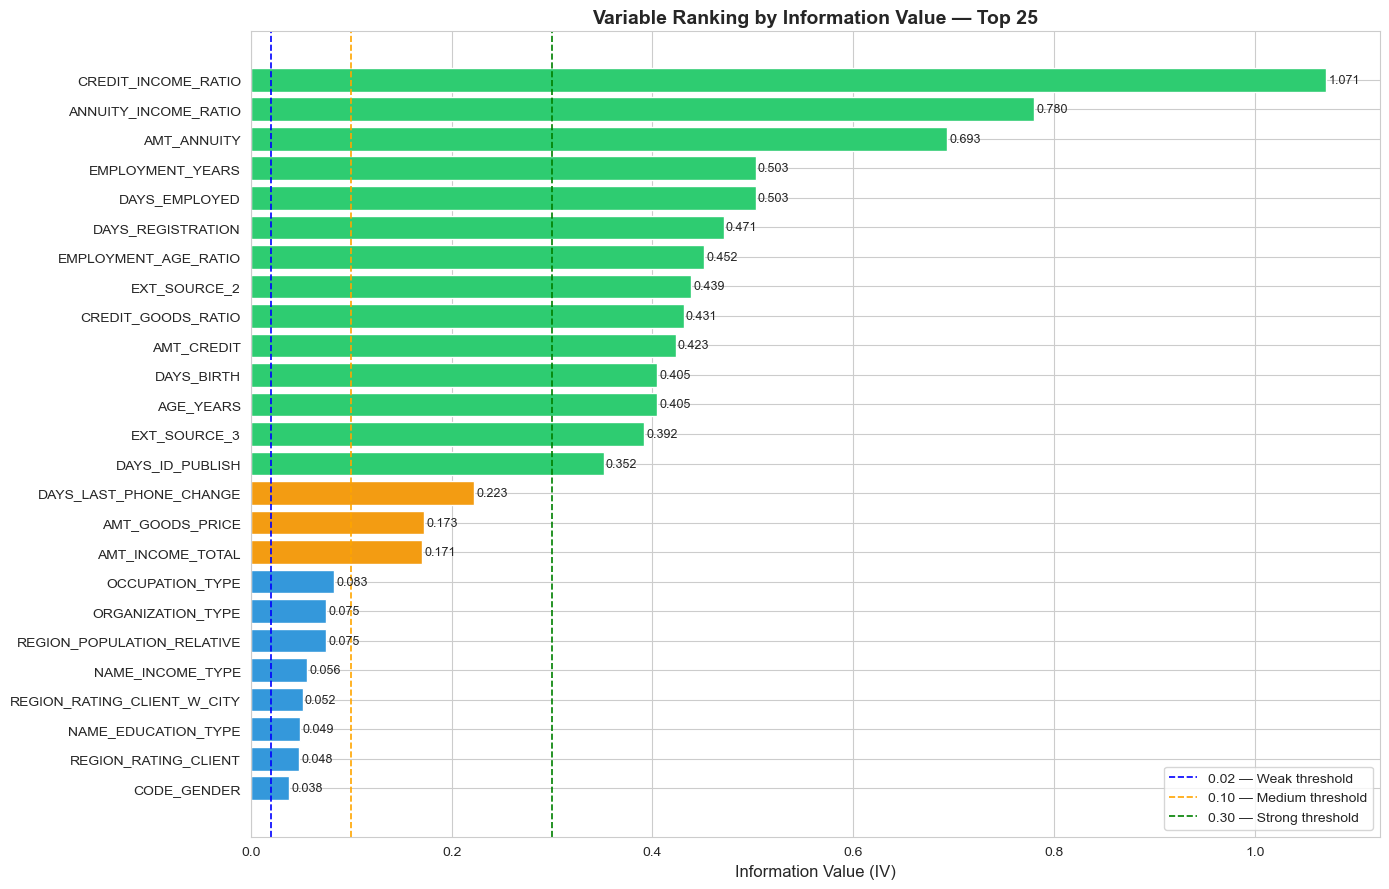

IV chart saved ✓


In [11]:
# ── IV bar chart — top 25 variables ──────────────────────────────────────────
top25 = iv_summary.head(25)

# Colour each bar by IV category
def iv_color(iv):
    if iv >= 0.30: return '#2ecc71'   # green  — strong
    elif iv >= 0.10: return '#f39c12' # orange — medium
    elif iv >= 0.02: return '#3498db' # blue   — weak
    else: return '#e74c3c'            # red    — useless

colors = [iv_color(iv) for iv in top25['IV']]

fig, ax = plt.subplots(figsize=(14, 9))
bars = ax.barh(top25['Variable'], top25['IV'], color=colors, edgecolor='white')

# Reference lines
ax.axvline(x=0.02, color='blue',   linestyle='--', linewidth=1.2, label='0.02 — Weak threshold')
ax.axvline(x=0.10, color='orange', linestyle='--', linewidth=1.2, label='0.10 — Medium threshold')
ax.axvline(x=0.30, color='green',  linestyle='--', linewidth=1.2, label='0.30 — Strong threshold')

# Value labels
for bar, iv in zip(bars, top25['IV']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{iv:.3f}', va='center', fontsize=9)

ax.set_xlabel('Information Value (IV)', fontsize=12)
ax.set_title('Variable Ranking by Information Value — Top 25', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(base, 'outputs', '11_iv_ranking.png'), dpi=150, bbox_inches='tight')
plt.show()
print('IV chart saved ✓')

In [12]:
# ── Select variables based on IV threshold ────────────────────────────────────
IV_MIN = 0.10   # minimum IV — medium predictor
IV_MAX = 0.50   # maximum IV — above this is suspicious

selected_vars = iv_summary[
    (iv_summary['IV'] >= IV_MIN) &
    (iv_summary['IV'] <  IV_MAX)
]['Variable'].tolist()

print(f'Variables selected (IV between {IV_MIN} and {IV_MAX}): {len(selected_vars)}')
print('\nSelected variables:')
for i, var in enumerate(selected_vars, 1):
    iv_val = iv_summary[iv_summary['Variable'] == var]['IV'].values[0]
    print(f'  {i:2}. {var:<45} IV: {iv_val:.4f}')

Variables selected (IV between 0.1 and 0.5): 12

Selected variables:
   1. DAYS_REGISTRATION                             IV: 0.4710
   2. EMPLOYMENT_AGE_RATIO                          IV: 0.4516
   3. EXT_SOURCE_2                                  IV: 0.4387
   4. CREDIT_GOODS_RATIO                            IV: 0.4314
   5. AMT_CREDIT                                    IV: 0.4231
   6. DAYS_BIRTH                                    IV: 0.4046
   7. AGE_YEARS                                     IV: 0.4046
   8. EXT_SOURCE_3                                  IV: 0.3920
   9. DAYS_ID_PUBLISH                               IV: 0.3515
  10. DAYS_LAST_PHONE_CHANGE                        IV: 0.2226
  11. AMT_GOODS_PRICE                               IV: 0.1729
  12. AMT_INCOME_TOTAL                              IV: 0.1706


In [13]:
# ── Additional manual review ──────────────────────────────────────────────────
# Check for DAYS columns — these are raw and we prefer the derived versions
# Remove raw DAYS columns if the derived version (YEARS) is already selected

days_to_remove = []
for var in selected_vars:
    if 'DAYS_' in var:
        derived = var.replace('DAYS_', '').replace('BIRTH', 'AGE_YEARS').replace('EMPLOYED', 'EMPLOYMENT_YEARS')
        if derived in selected_vars:
            days_to_remove.append(var)

if days_to_remove:
    print(f'Removing raw DAYS columns (derived versions preferred):')
    for col in days_to_remove:
        print(f'  Removing: {col}')
    selected_vars = [v for v in selected_vars if v not in days_to_remove]

print(f'\nFinal selected variable count: {len(selected_vars)}')

Removing raw DAYS columns (derived versions preferred):
  Removing: DAYS_BIRTH

Final selected variable count: 11


In [14]:
# ── Run WOE binning on selected variables ─────────────────────────────────────
# woebin calculates optimal bins and WOE values for each variable
# bins is a dictionary: {variable_name: bin_table_dataframe}

print('Running WOE binning on selected variables...')

# Subset train data to selected variables + target
train_selected = train_df[selected_vars + ['TARGET']].copy()

bins = sc.woebin(train_selected, y='TARGET')

print(f'WOE binning complete ✓')
print(f'Variables binned: {len(bins)}')

Running WOE binning on selected variables...
[INFO] creating woe binning ...


/Users/shivamverma/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:38: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_op

/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:414: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg({'good':sum, 'bad':sum}).reset_index()\
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:414: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg({'good':sum, 'bad':sum}).reset_index()\
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:414: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep curren

/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:425: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: iv_01(x['good'], x['bad'])).reset_index(name='total_iv')
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:442: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binning_1bst_brk = binning_1bst_brk.groupby(['variable', 'bstbin'], group_keys=False)\
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:443: FutureWarn

/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:414: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg({'good':sum, 'bad':sum}).reset_index()\
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:361: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  init_bin = init_bin.groupby('brkp', group_keys=False).agg({
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:414: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly.

...

/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:361: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  init_bin = init_bin.groupby('brkp', group_keys=False).agg({
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:361: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  init_bin = init_bin.groupby('brkp', group_keys=False).agg({
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:361: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be

/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:414: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg({'good':sum, 'bad':sum}).reset_index()\
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:414: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg({'good':sum, 'bad':sum}).reset_index()\
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:425: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operati

/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:425: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: iv_01(x['good'], x['bad'])).reset_index(name='total_iv')
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:442: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binning_1bst_brk = binning_1bst_brk.groupby(['variable', 'bstbin'], group_keys=False)\
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:443: FutureWarn

Binning on 246008 rows and 12 columns in 00:00:12
WOE binning complete ✓
Variables binned: 11


/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:425: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: iv_01(x['good'], x['bad'])).reset_index(name='total_iv')
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:442: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binning_1bst_brk = binning_1bst_brk.groupby(['variable', 'bstbin'], group_keys=False)\
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:443: FutureWarn

In [15]:
# ── View WOE bin table for a key variable ─────────────────────────────────────
# Let us look at AGE_YEARS as an example
# This shows exactly what we calculated manually in the WOE explanation

example_var = 'AGE_YEARS' if 'AGE_YEARS' in bins else selected_vars[0]

print(f'WOE Bin Table for: {example_var}')
print('='*80)
print(bins[example_var][['bin', 'count', 'count_distr',
                          'good', 'bad', 'badprob',
                          'woe', 'bin_iv', 'total_iv']].to_string(index=False))

print('\nColumn meanings:')
print('  bin        = bin range')
print('  count      = total applicants in this bin')
print('  count_distr= % of all applicants in this bin')
print('  good       = non-defaulters in this bin')
print('  bad        = defaulters in this bin')
print('  badprob    = default rate in this bin')
print('  woe        = Weight of Evidence')
print('  bin_iv     = IV contribution of this bin')
print('  total_iv   = total IV for this variable')

WOE Bin Table for: AGE_YEARS
        bin  count  count_distr  good  bad  badprob     woe  bin_iv  total_iv
[-inf,32.0)  49082       0.1995 43514 5568   0.1134  0.3764  0.0331    0.0858
[32.0,38.0)  38731       0.1574 35000 3731   0.0963  0.1938  0.0064    0.0858
[38.0,42.0)  27781       0.1129 25487 2294   0.0826  0.0246  0.0001    0.0858
[42.0,54.0)  69513       0.2826 64453 5060   0.0728 -0.1121  0.0034    0.0858
 [54.0,inf)  60901       0.2476 57694 3207   0.0527 -0.4573  0.0428    0.0858

Column meanings:
  bin        = bin range
  count      = total applicants in this bin
  count_distr= % of all applicants in this bin
  good       = non-defaulters in this bin
  bad        = defaulters in this bin
  badprob    = default rate in this bin
  woe        = Weight of Evidence
  bin_iv     = IV contribution of this bin
  total_iv   = total IV for this variable


In [16]:
# ── Custom WOE plot function ───────────────────────────────────────────────────
# scorecardpy has its own plot but we build a custom one
# for better control and professional appearance

def plot_woe_bin(bin_df, var_name, ax_woe, ax_dist):
    """
    Plot WOE values and distribution for a single variable.
    Shows two charts side by side:
    Left  — WOE value per bin (risk profile)
    Right — % distribution of good vs bad per bin
    """
    # Remove special rows like missing bin for cleaner display
    bin_df = bin_df[bin_df['bin'] != 'missing'].copy()
    bin_labels = bin_df['bin'].astype(str)
    x = range(len(bin_labels))

    # ── Left chart — WOE values ───────────────────────────────────────────
    colors_woe = ['#e74c3c' if w > 0 else '#2ecc71' for w in bin_df['woe']]
    bars = ax_woe.bar(x, bin_df['woe'], color=colors_woe, edgecolor='white', width=0.6)
    ax_woe.axhline(y=0, color='black', linewidth=1.5)
    ax_woe.plot(x, bin_df['woe'], 'o--', color='navy', linewidth=1.5, markersize=5)
    ax_woe.set_xticks(x)
    ax_woe.set_xticklabels(bin_labels, rotation=30, ha='right', fontsize=8)
    ax_woe.set_title(f'{var_name}\nWOE per Bin', fontsize=10, fontweight='bold')
    ax_woe.set_ylabel('WOE')

    # Add WOE value labels
    for bar, woe in zip(bars, bin_df['woe']):
        ax_woe.text(bar.get_x() + bar.get_width()/2,
                    woe + (0.02 if woe >= 0 else -0.05),
                    f'{woe:.2f}', ha='center', fontsize=8)

    # ── Right chart — default rate per bin ───────────────────────────────
    ax_dist.bar(x, bin_df['badprob'] * 100,
                color='#e67e22', edgecolor='white', alpha=0.8, width=0.6)
    ax_dist.axhline(y=bin_df['bad'].sum() / bin_df['count'].sum() * 100,
                    color='blue', linestyle='--', linewidth=1.5,
                    label='Overall default rate')
    ax_dist.set_xticks(x)
    ax_dist.set_xticklabels(bin_labels, rotation=30, ha='right', fontsize=8)
    ax_dist.set_title(f'{var_name}\nDefault Rate per Bin', fontsize=10, fontweight='bold')
    ax_dist.set_ylabel('Default Rate %')
    ax_dist.legend(fontsize=8)

print('WOE plot function defined ✓')

WOE plot function defined ✓


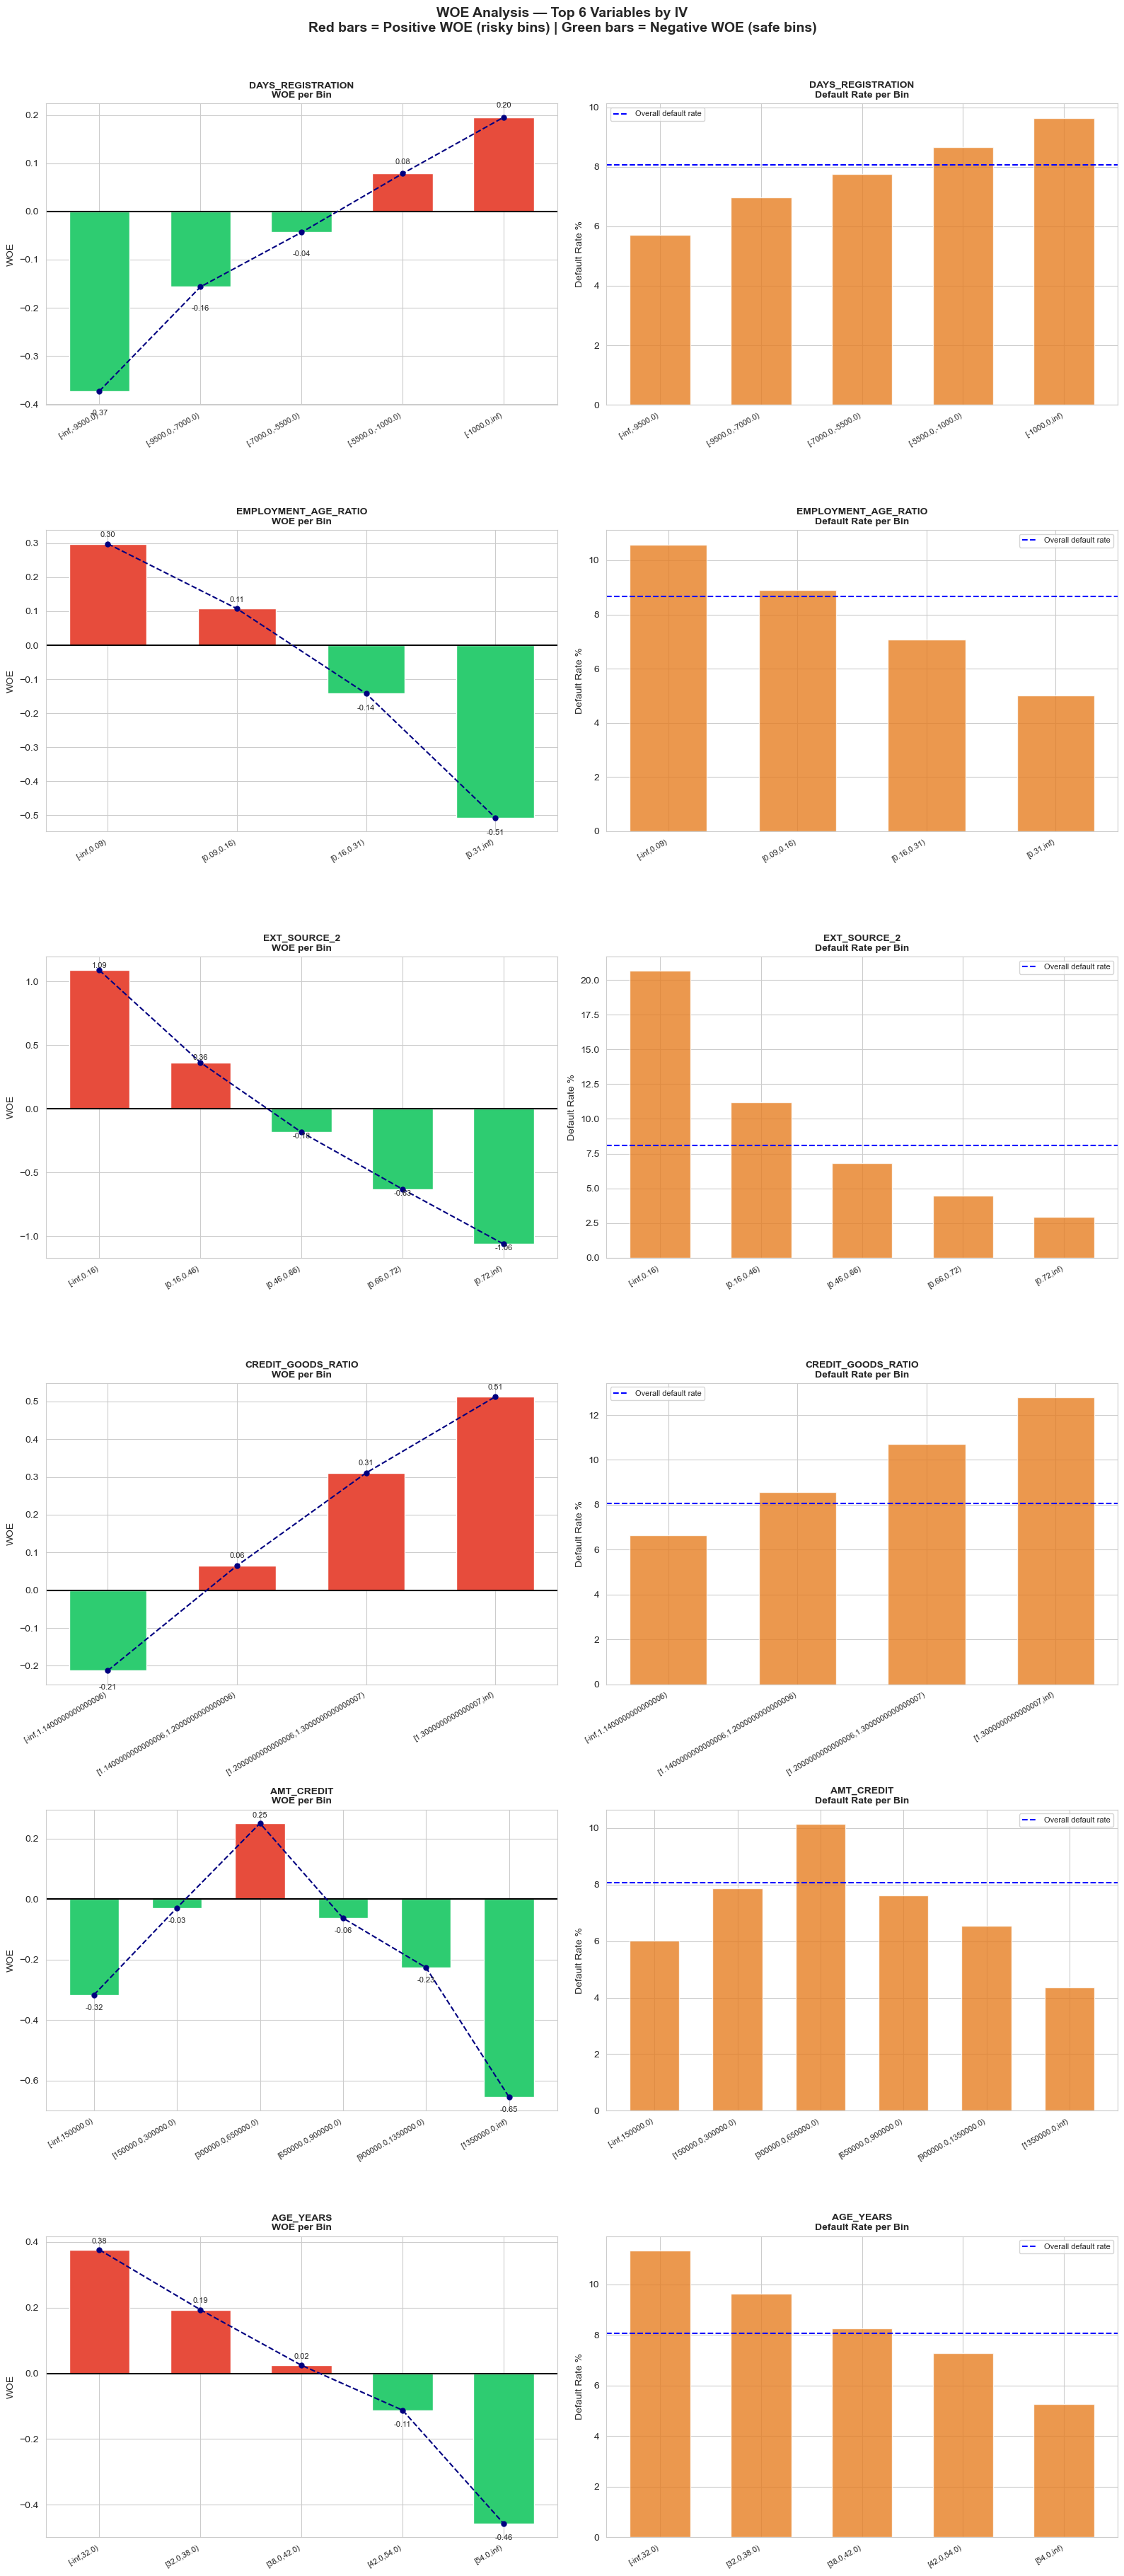

WOE plots saved ✓


In [17]:
# ── Plot top 6 variables by IV ────────────────────────────────────────────────
top6_vars = selected_vars[:6]

fig, axes = plt.subplots(6, 2, figsize=(16, 36))

for i, var in enumerate(top6_vars):
    if var in bins:
        plot_woe_bin(bins[var], var, axes[i, 0], axes[i, 1])

plt.suptitle('WOE Analysis — Top 6 Variables by IV\n'
             'Red bars = Positive WOE (risky bins) | Green bars = Negative WOE (safe bins)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(base, 'outputs', '12_woe_plots_top6.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('WOE plots saved ✓')

In [18]:
# ── Check WOE monotonicity for each selected variable ─────────────────────────
def check_monotonicity(bin_df):
    """
    Check if WOE values are monotonically increasing or decreasing.
    Returns: 'Increasing', 'Decreasing', or 'Non-Monotonic'
    """
    # Remove missing bin
    woe_vals = bin_df[bin_df['bin'] != 'missing']['woe'].values

    if len(woe_vals) <= 1:
        return 'Single Bin'

    diffs = np.diff(woe_vals)

    if all(d >= 0 for d in diffs):
        return 'Increasing ✅'
    elif all(d <= 0 for d in diffs):
        return 'Decreasing ✅'
    else:
        return 'Non-Monotonic ⚠️'

print('Monotonicity Check for Selected Variables')
print('='*65)
print(f'{"Variable":<45} {"IV":>8}  {"Monotonicity"}')
print('-'*65)

monotone_vars    = []
non_monotone_vars = []

for var in selected_vars:
    if var in bins:
        iv_val     = iv_summary[iv_summary['Variable'] == var]['IV'].values[0]
        monotone   = check_monotonicity(bins[var])
        print(f'{var:<45} {iv_val:>8.4f}  {monotone}')

        if '✅' in monotone:
            monotone_vars.append(var)
        else:
            non_monotone_vars.append(var)

print('='*65)
print(f'Monotonic     : {len(monotone_vars)}')
print(f'Non-Monotonic : {len(non_monotone_vars)}')

Monotonicity Check for Selected Variables
Variable                                            IV  Monotonicity
-----------------------------------------------------------------
DAYS_REGISTRATION                               0.4710  Increasing ✅
EMPLOYMENT_AGE_RATIO                            0.4516  Decreasing ✅
EXT_SOURCE_2                                    0.4387  Decreasing ✅
CREDIT_GOODS_RATIO                              0.4314  Increasing ✅
AMT_CREDIT                                      0.4231  Non-Monotonic ⚠️
AGE_YEARS                                       0.4046  Decreasing ✅
EXT_SOURCE_3                                    0.3920  Decreasing ✅
DAYS_ID_PUBLISH                                 0.3515  Increasing ✅
DAYS_LAST_PHONE_CHANGE                          0.2226  Increasing ✅
AMT_GOODS_PRICE                                 0.1729  Non-Monotonic ⚠️
AMT_INCOME_TOTAL                                0.1706  Decreasing ✅
Monotonic     : 9
Non-Monotonic : 2


In [19]:
# ── Apply WOE transformation to train and OOT ─────────────────────────────────
# woebin_ply applies the bins calculated on TRAIN to any dataset
# This is how we correctly apply train bins to OOT without leakage

# Transform train
train_woe = sc.woebin_ply(train_selected, bins)
train_woe['TARGET'] = train_df['TARGET'].values

# Transform OOT — using same bins from TRAIN
oot_selected        = oot_df[selected_vars + ['TARGET']].copy()
oot_woe             = sc.woebin_ply(oot_selected, bins)
oot_woe['TARGET']   = oot_df['TARGET'].values

print('WOE transformation complete ✓')
print(f'Train WOE shape: {train_woe.shape}')
print(f'OOT WOE shape  : {oot_woe.shape}')

print('\nFirst 3 rows of WOE transformed data (train):')
print(train_woe.head(3).T)

[INFO] converting into woe values ...


/Users/shivamverma/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Woe transformating on 246008 rows and 11 columns in 00:00:10
[INFO] converting into woe values ...


/Users/shivamverma/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


WOE transformation complete ✓
Train WOE shape: (246008, 12)
OOT WOE shape  : (61503, 12)

First 3 rows of WOE transformed data (train):
                            181648  229245  122525
TARGET                      0.0000  0.0000  1.0000
EXT_SOURCE_3_woe           -0.5865  0.1523 -0.5865
AMT_INCOME_TOTAL_woe        0.0472  0.0472  0.0472
AMT_CREDIT_woe             -0.0283 -0.0283 -0.0624
EMPLOYMENT_AGE_RATIO_woe    0.2986  0.2986  0.2986
DAYS_LAST_PHONE_CHANGE_woe  0.1415  0.1415 -0.2136
DAYS_REGISTRATION_woe      -0.0434  0.0786 -0.1565
AMT_GOODS_PRICE_woe         0.0463 -0.2216 -0.0362
DAYS_ID_PUBLISH_woe        -0.2612  0.0942  0.0942
CREDIT_GOODS_RATIO_woe      0.3107  0.0648  0.5124
AGE_YEARS_woe               0.1938 -0.1121 -0.1121
EXT_SOURCE_2_woe            0.3631 -0.1850 -0.1850


In [20]:
# ── Verify WOE transformation ─────────────────────────────────────────────────
# After transformation:
# 1. All columns should be numerical (WOE values)
# 2. No missing values should remain
# 3. Column names have _woe suffix added by scorecardpy

print('WOE Transformation Verification')
print('='*45)
print(f'Missing values in train_woe: {train_woe.isnull().sum().sum()}')
print(f'Missing values in oot_woe  : {oot_woe.isnull().sum().sum()}')
print(f'Data types — all numeric   : {all(train_woe.dtypes != "object")}')
print(f'\nColumn names sample:')
print(list(train_woe.columns[:8]))

WOE Transformation Verification
Missing values in train_woe: 0
Missing values in oot_woe  : 0
Data types — all numeric   : True

Column names sample:
['TARGET', 'EXT_SOURCE_3_woe', 'AMT_INCOME_TOTAL_woe', 'AMT_CREDIT_woe', 'EMPLOYMENT_AGE_RATIO_woe', 'DAYS_LAST_PHONE_CHANGE_woe', 'DAYS_REGISTRATION_woe', 'AMT_GOODS_PRICE_woe']


In [21]:
# ── Calculate PSI for all selected variables ──────────────────────────────────
def calculate_psi(train_series, oot_series, bins_dict, var_name):
    """
    Calculate Population Stability Index between train and OOT
    using the WOE bin boundaries already calculated.
    """
    bin_table = bins_dict[var_name]
    bin_table = bin_table[bin_table['bin'] != 'missing']

    train_dist = train_series.value_counts(normalize=True)
    oot_dist   = oot_series.value_counts(normalize=True)

    # Align indices
    all_bins = train_dist.index.union(oot_dist.index)
    train_dist = train_dist.reindex(all_bins, fill_value=0.0001)
    oot_dist   = oot_dist.reindex(all_bins, fill_value=0.0001)

    psi = np.sum((oot_dist - train_dist) * np.log(oot_dist / train_dist))
    return abs(psi)

# Calculate PSI using WOE transformed columns
psi_results = []

for var in selected_vars:
    woe_col = var + '_woe'
    if woe_col in train_woe.columns and woe_col in oot_woe.columns:
        psi_val = calculate_psi(
            train_woe[woe_col],
            oot_woe[woe_col],
            bins, var
        )
        status = '✅ Stable' if psi_val < 0.10 else '⚠️ Monitor' if psi_val < 0.25 else '❌ Unstable'
        psi_results.append({'Variable': var, 'PSI': round(psi_val, 4), 'Status': status})

psi_df = pd.DataFrame(psi_results).sort_values('PSI', ascending=False)
print('PSI Results — Train vs OOT')
print('='*55)
print(psi_df.to_string(index=False))

# Save PSI results
psi_df.to_csv(os.path.join(base, 'outputs', 'psi_results.csv'), index=False)
print('\nPSI results saved ✓')

PSI Results — Train vs OOT
              Variable    PSI   Status
DAYS_LAST_PHONE_CHANGE 0.0003 ✅ Stable
     DAYS_REGISTRATION 0.0002 ✅ Stable
          EXT_SOURCE_3 0.0002 ✅ Stable
  EMPLOYMENT_AGE_RATIO 0.0001 ✅ Stable
             AGE_YEARS 0.0001 ✅ Stable
       DAYS_ID_PUBLISH 0.0001 ✅ Stable
       AMT_GOODS_PRICE 0.0001 ✅ Stable
          EXT_SOURCE_2 0.0000 ✅ Stable
    CREDIT_GOODS_RATIO 0.0000 ✅ Stable
            AMT_CREDIT 0.0000 ✅ Stable
      AMT_INCOME_TOTAL 0.0000 ✅ Stable

PSI results saved ✓


In [22]:
# ── Final shortlist combining IV + PSI + Monotonicity ─────────────────────────
stable_vars = psi_df[psi_df['PSI'] < 0.25]['Variable'].tolist()
final_vars  = [v for v in stable_vars if v in monotone_vars or v in selected_vars]

# Limit to top 15 for scorecard — industry standard is 8-15 variables
final_vars = final_vars[:15]

print('FINAL VARIABLE SHORTLIST FOR SCORECARD')
print('='*65)
print(f'Total variables passing all criteria: {len(final_vars)}')
print()

for i, var in enumerate(final_vars, 1):
    iv_val  = iv_summary[iv_summary['Variable'] == var]['IV'].values[0]
    psi_val = psi_df[psi_df['Variable'] == var]['PSI'].values
    psi_val = psi_val[0] if len(psi_val) > 0 else 0
    mono    = check_monotonicity(bins[var]) if var in bins else 'N/A'
    print(f'{i:2}. {var:<40} IV: {iv_val:.3f}  PSI: {psi_val:.3f}  {mono}')

# Save final variable list
pd.DataFrame({'Final_Variables': final_vars}).to_csv(
    os.path.join(base, 'outputs', 'final_variable_list.csv'), index=False)
print('\nFinal variable list saved ✓')

FINAL VARIABLE SHORTLIST FOR SCORECARD
Total variables passing all criteria: 11

 1. DAYS_LAST_PHONE_CHANGE                   IV: 0.223  PSI: 0.000  Increasing ✅
 2. DAYS_REGISTRATION                        IV: 0.471  PSI: 0.000  Increasing ✅
 3. EXT_SOURCE_3                             IV: 0.392  PSI: 0.000  Decreasing ✅
 4. EMPLOYMENT_AGE_RATIO                     IV: 0.452  PSI: 0.000  Decreasing ✅
 5. AGE_YEARS                                IV: 0.405  PSI: 0.000  Decreasing ✅
 6. DAYS_ID_PUBLISH                          IV: 0.352  PSI: 0.000  Increasing ✅
 7. AMT_GOODS_PRICE                          IV: 0.173  PSI: 0.000  Non-Monotonic ⚠️
 8. EXT_SOURCE_2                             IV: 0.439  PSI: 0.000  Decreasing ✅
 9. CREDIT_GOODS_RATIO                       IV: 0.431  PSI: 0.000  Increasing ✅
10. AMT_CREDIT                               IV: 0.423  PSI: 0.000  Non-Monotonic ⚠️
11. AMT_INCOME_TOTAL                         IV: 0.171  PSI: 0.000  Decreasing ✅

Final variable list

In [23]:
# ── Save final WOE datasets for logistic regression notebook ──────────────────
# Only keep the final selected variables in WOE form

final_woe_cols = [v + '_woe' for v in final_vars if v + '_woe' in train_woe.columns]

train_final = train_woe[final_woe_cols + ['TARGET']].copy()
oot_final   = oot_woe[final_woe_cols + ['TARGET']].copy()

# Save to data folder
train_final.to_csv(os.path.join(base, 'data', 'train_woe.csv'), index=False)
oot_final.to_csv(os.path.join(base, 'data', 'oot_woe.csv'),   index=False)

print('WOE datasets saved ✓')
print(f'train_woe.csv : {train_final.shape}')
print(f'oot_woe.csv   : {oot_final.shape}')

WOE datasets saved ✓
train_woe.csv : (246008, 12)
oot_woe.csv   : (61503, 12)


In [24]:
print('='*65)
print('  WOE / IV BINNING SUMMARY')
print('='*65)
print(f"""
INPUT
  Variables analysed     : {len(valid_cols)}
  Training records       : {len(train_df):,}

IV ANALYSIS
  Strong (IV >= 0.30)    : {len(iv_summary[iv_summary['IV'] >= 0.30])}
  Medium (0.10-0.30)     : {len(iv_summary[(iv_summary['IV'] >= 0.10) & (iv_summary['IV'] < 0.30)])}
  Weak   (0.02-0.10)     : {len(iv_summary[(iv_summary['IV'] >= 0.02) & (iv_summary['IV'] < 0.10)])}
  Useless (< 0.02)       : {len(iv_summary[iv_summary['IV'] < 0.02])}

VARIABLE SELECTION
  After IV filter        : {len(selected_vars)}
  After PSI filter       : {len(stable_vars)}
  Final shortlist        : {len(final_vars)}

OUTPUTS SAVED
  iv_summary.csv         → IV for all variables
  psi_results.csv        → PSI train vs OOT
  final_variable_list.csv→ Final scorecard variables
  train_woe.csv          → WOE transformed train set
  oot_woe.csv            → WOE transformed OOT set
  11_iv_ranking.png      → IV bar chart
  12_woe_plots_top6.png  → WOE bin plots
""")
print('='*65)
print('  NEXT: 04_logistic_regression_scorecard.ipynb')
print('='*65)

  WOE / IV BINNING SUMMARY

INPUT
  Variables analysed     : 78
  Training records       : 246,008

IV ANALYSIS
  Strong (IV >= 0.30)    : 14
  Medium (0.10-0.30)     : 3
  Weak   (0.02-0.10)     : 13
  Useless (< 0.02)       : 47

VARIABLE SELECTION
  After IV filter        : 11
  After PSI filter       : 11
  Final shortlist        : 11

OUTPUTS SAVED
  iv_summary.csv         → IV for all variables
  psi_results.csv        → PSI train vs OOT
  final_variable_list.csv→ Final scorecard variables
  train_woe.csv          → WOE transformed train set
  oot_woe.csv            → WOE transformed OOT set
  11_iv_ranking.png      → IV bar chart
  12_woe_plots_top6.png  → WOE bin plots

  NEXT: 04_logistic_regression_scorecard.ipynb
